In [1]:
# imports
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import re
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import pickle
import time
import os
from sklearn.metrics import f1_score, accuracy_score, precision_score, classification_report


In [2]:
# class definitions

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]

# Type of Transformer classifier
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        d_model: int,
        nhead: int ,
        num_layers: int,
        dim_feedforward: int,
        dropout: float ,
        max_len: int ,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        center_idx = x.size(1) // 2
        x = self.norm(x[:, center_idx, :])
        return self.classifier(x)




In [3]:
# function definitions

# Sliding windows
def make_windows(X: np.ndarray, y: np.ndarray, window: int, hop: int = 1):
    """Build sliding windows and use the center-symbol label as window target."""
    if len(X) < window:
        raise ValueError(f"Need at least {window} symbols, got {len(X)}")

    Xw, yw = [], []
    center = window // 2
    for start in range(0, len(X) - window + 1, hop):
        end = start + window
        Xw.append(X[start:end])
        yw.append(y[start + center])

    return np.stack(Xw).astype(np.float32), np.array(yw, dtype=np.int64)



def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * yb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += yb.size(0)

    return total_loss / total_count, total_correct / total_count


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def get_model_size_mb(model, path="temp_model.pth"):
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    os.remove(path)
    return size_mb

def totalEvaulation(model, test_loader, device,pipeLine = "Pipeline structure - Placeholder", CM_title = "Model Performance Evaluation - Placeholder",CM_SaveName = "CM Save Name Placeholder", fileName = "model_metrics_placeholder", num_classes=4):
    model.eval()
    num_classes = M
    #path = f"{model.name()}.pth"
    torch.save(model.state_dict(), "modelSnapshot.pth")
    path = "modelSnapshot.pth"
    preds = []
    targets = []
    file_sizes = []
    accuracies = []
    total_times = []
    avg_times_per_sample = []
    avg_times_per_batch = []
    parameter_counts = []
    classification_reports = []
    torch.save(model.state_dict(), path)
    dataType = model.parameters().__next__().dtype
    bit_width = re.findall(r'[0-9]+', str(dataType))[0]
    
    intraDataFrame = pd.DataFrame({
    #"Pipeline" : [pipeLine],
    "Accuracy":[],
    "Precision" : [],
    "F1-score":[],
    "Total Inference time": [],
    "Batch Inference time":[],
    "Est. Sample Inference time": [],
    "Total parameters":[],
    "Memory footprint":[],
    "Data type":[],
    "Bit width":[]
    })
    

    n_samples = 0 # variable to hold how many samples through all batches
    batch_inference_times = []
    with torch.no_grad():
        for x_batch, y_batch, in test_loader:
            x_batch = x_batch.to(device)
            if device.type == "cuda": # synchronize cuda before measuring the time
                torch.cuda.synchronize()
            start_time = time.perf_counter()  # start time to measure inference (batch?)
            #outputs = prune_increment_model(x_batch)
            outputs = model(x_batch)
            predicted = torch.argmax(outputs, dim=1).cpu().numpy()
            if device.type == "cuda": # synchronize cuda before measuring the time
                torch.cuda.synchronize()
            end_time = time.perf_counter()  # end time to measure inference (batch?)
            preds.extend(predicted)
            targets.extend(y_batch.cpu())

            n_samples += x_batch.size(0)
            batch_inference_time = end_time - start_time
            batch_inference_times.append(batch_inference_time)
    
    report_dict = classification_report(targets, preds, output_dict=True, zero_division=0)
    cm = confusion_matrix(targets, preds)

    total_time = np.sum(batch_inference_times)
    avg_time_per_sample = total_time/n_samples
    avg_time_per_batch = np.mean(batch_inference_times)

    total_parameters, trainable_parameters = count_parameters(model)
    accuracy = accuracy_score(targets,preds)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    accuracies.append(accuracy) #calculate current accuracy
    total_times.append(total_time)
    avg_times_per_sample.append(avg_time_per_sample)
    avg_times_per_batch.append(avg_time_per_batch)
    parameter_counts.append(total_parameters)
    classification_reports.append(report_dict)

    #cmap = plt.colormaps.get_cmap("Blues")
    #disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    #disp.plot(cmap=cmap)
    #plt.title(f"{CM_title}")
    #plt.show()
    #plt.savefig(f"{CM_title}.png")
    

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.arange(num_classes),
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=0,
    )

    ax.set_title(f"{CM_title}")
    plt.tight_layout()
    plt.savefig(f"{CM_SaveName}.png", dpi=1200, bbox_inches="tight")
    plt.show()



    Performance_metrics_line = pd.DataFrame({
    
    "Accuracy":[accuracy],
    "F1-score":[report_dict["macro avg"]["f1-score"]],
    "Precision":[report_dict["macro avg"]["precision"]],
    "Total Inference time": [total_times[-1]],
    "Batch Inference time":[avg_times_per_batch[-1]],
    "Est. Sample Inference time": [avg_times_per_sample[-1]],
    "Total parameters":[total_parameters],
    "Memory footprint":[size_mb],
    "Data type":[dataType],
    "Bit width":[bit_width]
    })
    Performance_metrics_dataframe = pd.concat([intraDataFrame,Performance_metrics_line])
    
    savedData = pickle.dump(Performance_metrics_dataframe, open(f"{fileName}.pkl", "wb"))
    return Performance_metrics_dataframe


In [4]:
# just use csv_path for a single file instead of this silliness

#data_dir = Path(r"C:\Users\emils\Documents\GitHub\6G_inFactory\1. trainingWithRayleigh")
#data_dir = Path(r"C:\GitHub\6G_inFactory\1. trainingWithRayleigh")
#data_dir = Path(r"C:\GitHub Clones\6G_inFactory\1. trainingWithRayleigh")

In [5]:
### Training on Rician Channel fading K = 2.16
# csv_path = sorted(data_dir.glob("1. trainingWithRayleigh/16qam_noisy_with_labels_rician_fading_k_2.16.csv"))
csv_path = Path(r"C:\Users\mikep\Documents\GitHub\Compression-of-Wireless-Multi-Modal-Foundation-Models\16qam_noisy_with_labels_rician_fading_k_2.16.csv")

torch.manual_seed(42)
np.random.seed(42)
M = 16
# Parameters
seq_len = 128
stride = 32
batch_size = 256
num_epochs = 100
learning_rate = 1e-3
weight_decay = 1e-4

#device usage - CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Load synthetic QAM symbol-level data
dfs = []

df_all = pd.read_csv(csv_path)

#for file in csv_path:
#    df = pd.read_csv(file)
#    dfs.append(df)
#df_all = pd.concat(dfs, ignore_index=True)

required_cols = ["noisy_I", "noisy_Q", "clean_I", "clean_Q", "label_index"]
missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise ValueError(f"Missing columns in {csv_path}: {missing}")

# Labels
y_symbol = df_all["label_index"].to_numpy(dtype=np.int64)

# Clean input for training
X_clean = df_all[["clean_I", "clean_Q"]].to_numpy(dtype=np.float32)

# Noisy input for validation/testing
X_noisy = df_all[["noisy_I", "noisy_Q"]].to_numpy(dtype=np.float32)

num_classes = int(y_symbol.max()) + 1
print(f"Loaded {len(df_all)} symbols | classes: {num_classes}")



# Split on symbol stream first to avoid overlap leakage across splits
n_total = len(y_symbol)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)

# Train on clean
X_train_sym = X_noisy[:n_train]
y_train_sym = y_symbol[:n_train]

# Validate on noisy
X_val_sym = X_noisy[n_train : n_train + n_val]
y_val_sym = y_symbol[n_train : n_train + n_val]

# Test on noisy
X_test_sym = X_noisy[n_train + n_val :]
y_test_sym = y_symbol[n_train + n_val :]

X_train, y_train = make_windows(X_train_sym, y_train_sym, seq_len, stride)
X_val, y_val = make_windows(X_val_sym, y_val_sym, seq_len, stride)
X_test, y_test = make_windows(X_test_sym, y_test_sym, seq_len, stride)

print("Windowed shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


# Training - Validation - Test Datasets
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Train/Val/Test windows: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")


model = TransformerClassifier(
    input_dim=2,
    num_classes=num_classes,
    d_model=64,
    nhead=8,
    num_layers=32,
    dim_feedforward=512,
    dropout=0.3,
    max_len=seq_len,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
no_new_learning_counter = 0
no__new_learning_patience = 3  # 3 epochs of patience for not learning
lowest_loss = float("inf")  

epoch_count = 0
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )
    epoch_count += 1
    if val_loss < lowest_loss:
        lowest_loss = val_loss
        no_new_learning_counter = 0
    else:
        no_new_learning_counter += 1

    if no_new_learning_counter >= no__new_learning_patience:
        break

    

# Final test evaluation + confusion matrix
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
print(f"\nTest loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")


Using device: cuda
Loaded 200000 symbols | classes: 16
Windowed shapes:
Train: (4997, 128, 2) (4997,)
Val:   (622, 128, 2) (622,)
Test:  (622, 128, 2) (622,)
Train/Val/Test windows: 4997/622/622


C:\Users\mikep\AppData\Local\Temp\ipykernel_20044\2426213624.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


KeyboardInterrupt: 

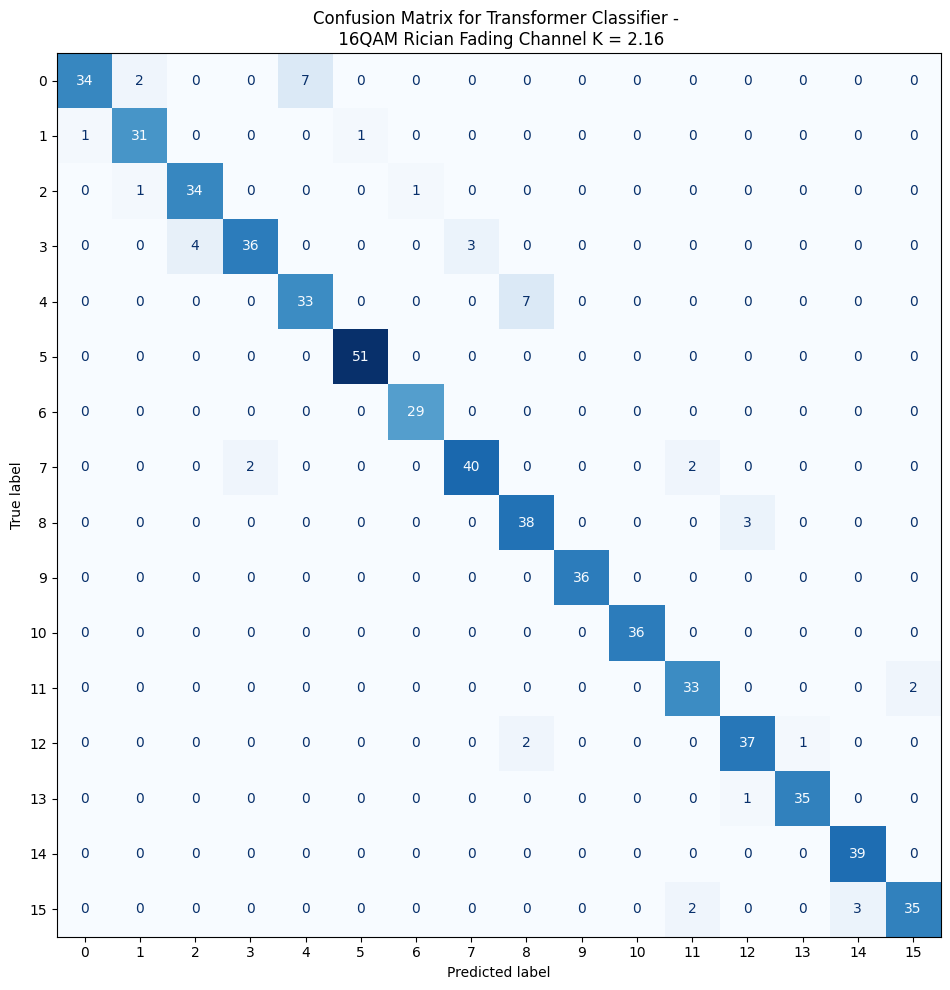

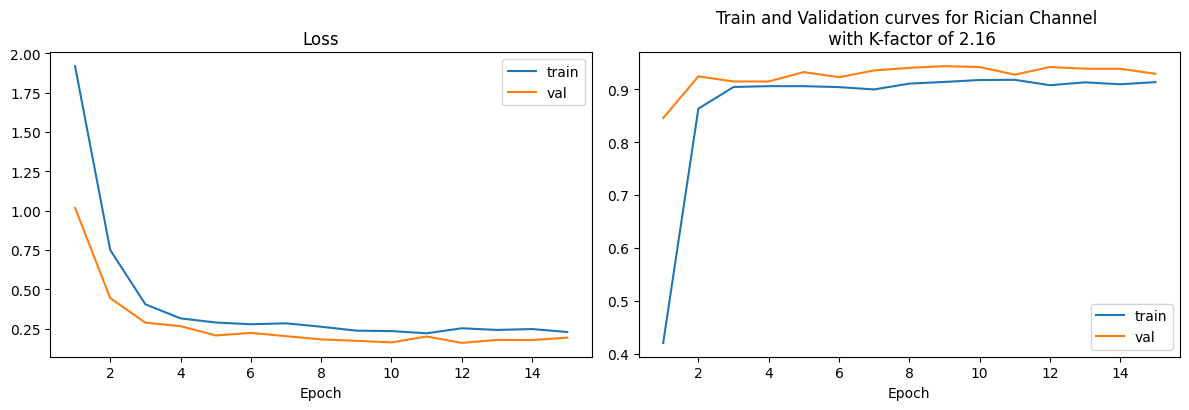

In [ ]:

totalEvaulation(model, test_loader, device,pipeLine = f"Transformer Classifier - {M}QAM Rician Channel Fading K=2.16", CM_title = f"Confusion Matrix for Transformer Classifier - \n {M}QAM Rician Fading Channel K = 2.16",CM_SaveName = f"CM_Transformer_{M}QAM_Rician_Fading", fileName =  f"Transformer_{M}QAM_Rician_Fading_Channel")

# Training curves
epochs = np.arange(1, epoch_count + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
#figureSavepath = str()
plt.tight_layout()
plt.title(f"Train and Validation curves for Rician Channel \n with K-factor of 2.16")
plt.savefig(f"training_curves_transformer_rician_channel.png", dpi=800, bbox_inches="tight")
plt.show()

